# Input cleaned_data

In [37]:
import pandas as pd
# 加载数据集
df = pd.read_csv('cleaned_youtube_data.csv')
# 查看数据的基本信息
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   rank                                637 non-null    int64  
 1   subscribers                         637 non-null    int64  
 2   video_views                         637 non-null    float64
 3   uploads                             637 non-null    float64
 4   country                             637 non-null    object 
 5   channel_type                        637 non-null    object 
 6   video_views_rank                    637 non-null    float64
 7   country_rank                        637 non-null    float64
 8   channel_type_rank                   637 non-null    float64
 9   video_views_30_days                 637 non-null    float64
 10  lowest_monthly_earnings             637 non-null    float64
 11  highest_monthly_earnings            637 non-n

## Data standardized  

In [38]:
import pandas as pd

# Convert categorical variables to numbers
df['country_code'] = pd.factorize(df['country'])[0]
df['channel_type_code'] = pd.factorize(df['channel_type'])[0]

# transform creation_date to datetime
df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

# delete non-numerical type coulmns
df.drop(columns=['country', 'channel_type', 'creation_month', 'date_string','creation_date'], inplace=True)

# 确保数值型数据的类型
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].astype(float)  # 将所有数值型特征转换为 float

# check data types
print(df.dtypes)

rank                                  float64
subscribers                           float64
video_views                           float64
uploads                               float64
video_views_rank                      float64
country_rank                          float64
channel_type_rank                     float64
video_views_30_days                   float64
lowest_monthly_earnings               float64
highest_monthly_earnings              float64
lowest_yearly_earnings                float64
highest_yearly_earnings               float64
subscribers_30_days                   float64
creation_year                         float64
tertiary_education_enrollment_rate    float64
population                            float64
unemployment_rate                     float64
urban_population                      float64
latitude                              float64
longitude                             float64
duration_days                         float64
country_code                      

# 2.Feature screening:
* 1. Standardize data
* 2. Apply PCA
* 3. Check the explained variance of principal components
* 4. Draw a scree plot for visualization
* 5. Select principal components based on
* 6. Transform the standardized data to obtain principal components

In [39]:
#Standardize Data
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [40]:
#应用 PCA
from sklearn.decomposition import PCA

pca = PCA()  
pca.fit(scaled_data)

PCA()

In [41]:
#View the variance of the principal components:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

# Calculate the cumulative variance explained
cumulative_explained_variance = np.cumsum(explained_variance)
print(cumulative_explained_variance)

[2.75543498e-01 1.29395475e-01 1.20499414e-01 1.03747150e-01
 8.64215063e-02 5.99715054e-02 4.17468707e-02 4.06991643e-02
 3.44246959e-02 2.45543739e-02 2.14634187e-02 1.54626536e-02
 1.53177667e-02 1.07799366e-02 8.74406707e-03 5.09833031e-03
 3.61100536e-03 1.88239019e-03 5.42479519e-04 8.35457074e-05
 7.71780200e-06 2.94803381e-06 8.79421364e-08]
[0.2755435  0.40493897 0.52543839 0.62918554 0.71560704 0.77557855
 0.81732542 0.85802458 0.89244928 0.91700365 0.93846707 0.95392972
 0.96924749 0.98002743 0.9887715  0.99386983 0.99748083 0.99936322
 0.9999057  0.99998925 0.99999696 0.99999991 1.        ]


In [48]:
pca = PCA()
pca.fit(scaled_data)

# loading dataframe
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=df.columns)
# print(loadings_df)


In [47]:
absolute_loadings = loadings_df.abs()

# Output the original variables whose contribution value in each principal component direction exceeds 50%
for pc in absolute_loadings.columns:
    significant_vars = absolute_loadings[pc][absolute_loadings[pc] > 0.5]
    if not significant_vars.empty:
        print(f"主成分 {pc} 的贡献值超过 50% 的原始变量:")
        for var, value in significant_vars.items():
            print(f"  - {var}: {value:.4f}")

主成分 PC1 的贡献值超过 50% 的原始变量:
  - subscribers: 0.5790
  - video_views: 0.6548
  - video_views_30_days: 0.9141
  - lowest_monthly_earnings: 0.9647
  - highest_monthly_earnings: 0.9646
  - lowest_yearly_earnings: 0.9645
  - highest_yearly_earnings: 0.9647
  - subscribers_30_days: 0.6861
主成分 PC2 的贡献值超过 50% 的原始变量:
  - tertiary_education_enrollment_rate: 0.8312
  - unemployment_rate: 0.8486
  - longitude: 0.7508
主成分 PC3 的贡献值超过 50% 的原始变量:
  - video_views_rank: 0.6060
  - channel_type_rank: 0.6073
  - population: 0.8015
  - urban_population: 0.7907
  - country_code: 0.5510
主成分 PC4 的贡献值超过 50% 的原始变量:
  - creation_year: 0.7901
  - duration_days: 0.7897
主成分 PC5 的贡献值超过 50% 的原始变量:
  - video_views_rank: 0.5715
  - country_rank: 0.6597
  - channel_type_rank: 0.5700
  - urban_population: 0.5326
主成分 PC6 的贡献值超过 50% 的原始变量:
  - rank: 0.5575
主成分 PC7 的贡献值超过 50% 的原始变量:
  - latitude: 0.6311
主成分 PC8 的贡献值超过 50% 的原始变量:
  - channel_type_code: 0.8382
主成分 PC9 的贡献值超过 50% 的原始变量:
  - uploads: 0.5589


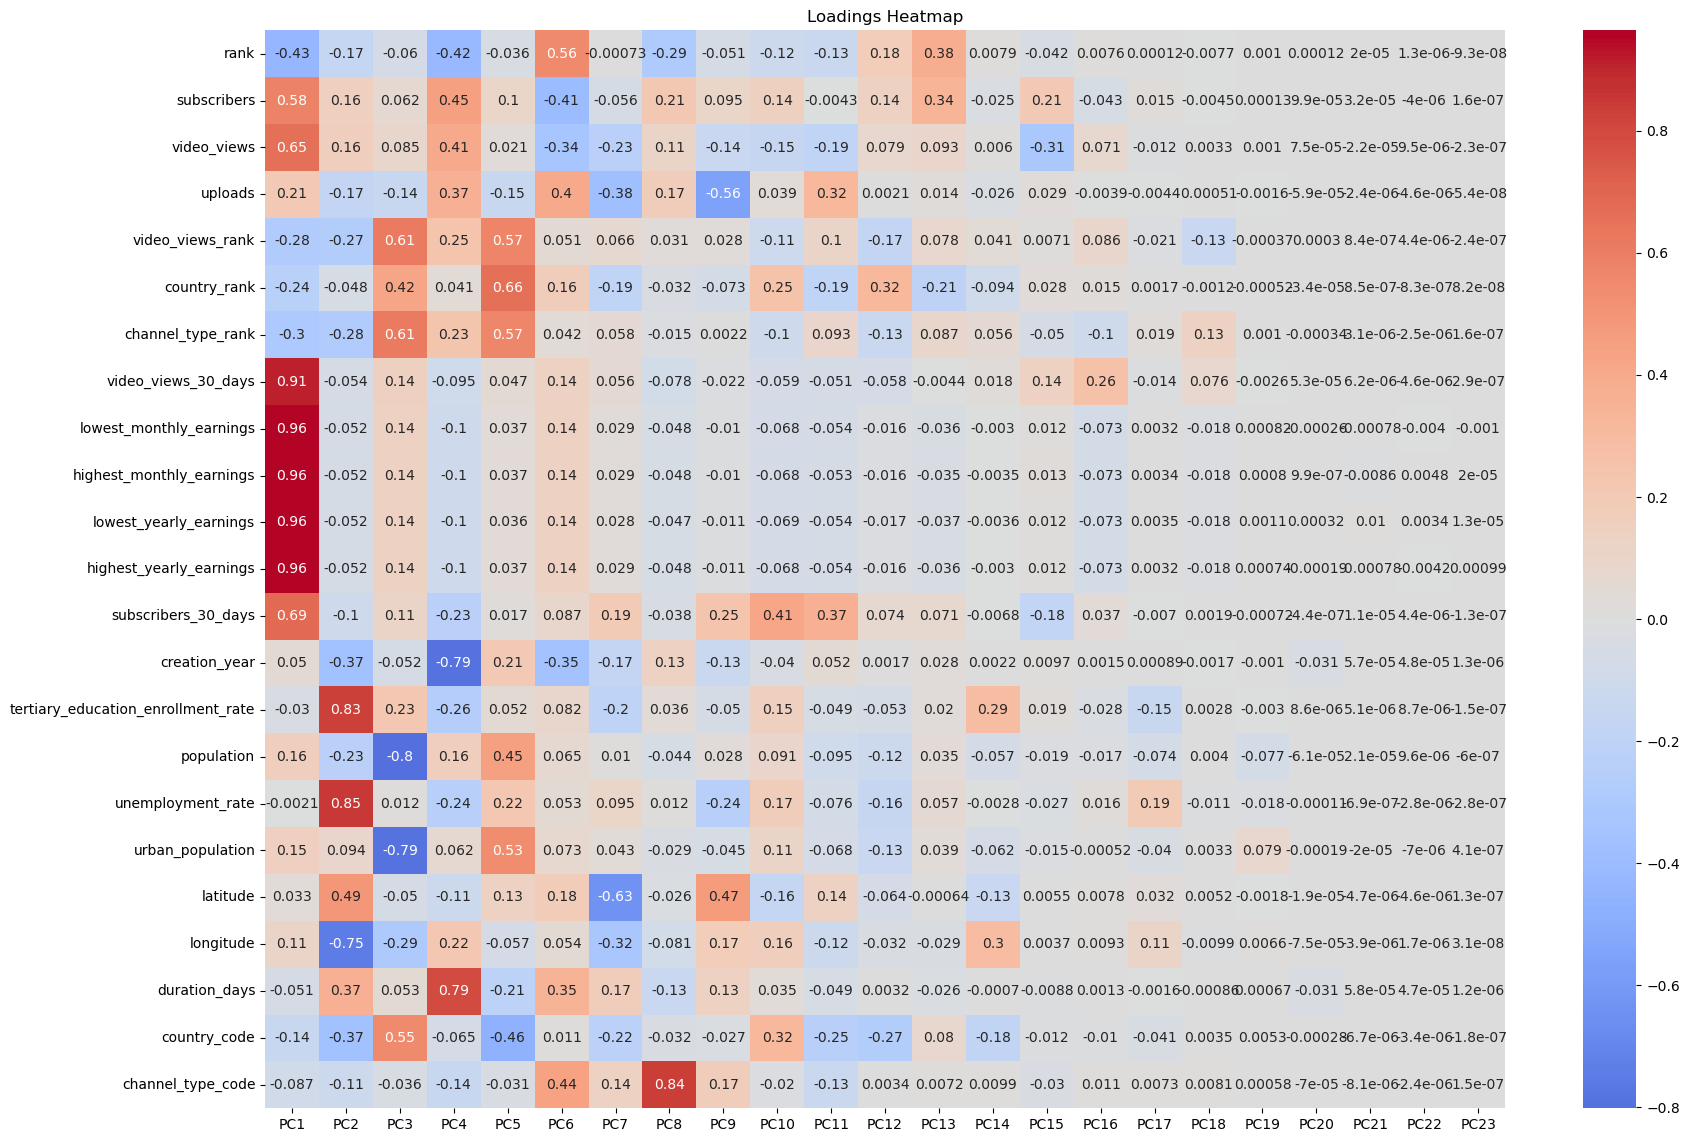

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 14))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0)
plt.title('Loadings Heatmap')
plt.show()

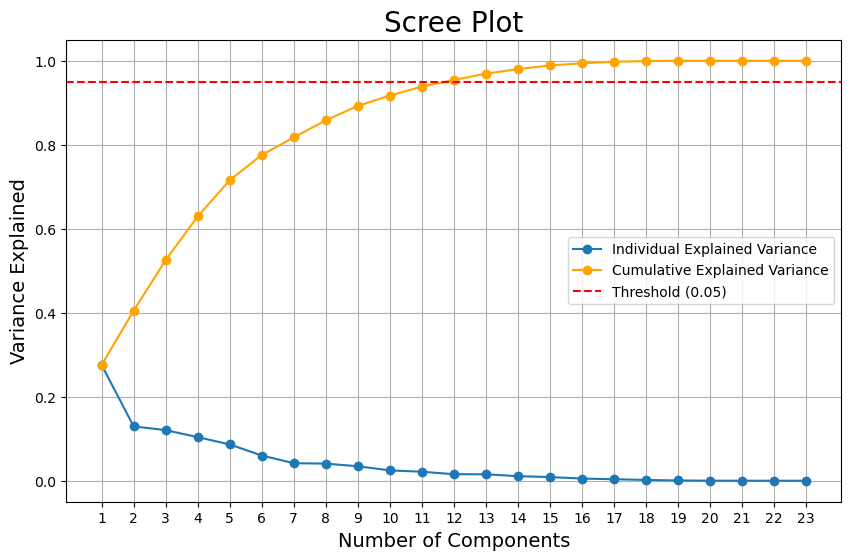

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the variance explained proportion
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', label='Individual Explained Variance')

# Plotting the cumulative variance explained
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', color='orange', label='Cumulative Explained Variance')

# Add a title and tags
plt.title('Scree Plot', fontsize=20)
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Variance Explained', fontsize=14)
plt.xticks(range(1, len(explained_variance) + 1))

# Add a horizontal line
plt.axhline(y=0.95, color='r', linestyle='--', label='Threshold (0.05)')  # 可添加水平线帮助观察
plt.legend()
plt.grid()
plt.show()

In [25]:
feature_names= ['rank', 'subscribers', 'video_views', 'uploads', 'video_views_rank',
       'country_rank', 'channel_type_rank', 'video_views_30_days',
       'lowest_monthly_earnings', 'highest_monthly_earnings',
       'lowest_yearly_earnings', 'highest_yearly_earnings',
       'subscribers_30_days', 'creation_year',
       'tertiary_education_enrollment_rate', 'population', 'unemployment_rate',
       'urban_population', 'latitude', 'longitude', 'duration_days',
       'country_code', 'channel_type_code']
# df.columns

In [49]:
#Selecting principal components
n_components = 9  
pca = PCA(n_components=n_components)

#Transform the data to obtain a low-dimensional representation
transformed_data = pca.fit_transform(scaled_data)
transformed_data

array([[13.26196837,  0.39062272,  0.36944934, ...,  0.06656601,
         0.91423962,  1.61003812],
       [13.4677351 ,  1.90727139,  2.82443974, ...,  2.35593757,
         0.2807068 ,  3.6706811 ],
       [11.4082543 ,  3.25962098,  2.34712659, ...,  0.137737  ,
         0.81489476,  0.53300898],
       ...,
       [-2.60941481,  0.40860074,  0.83624587, ..., -0.49689491,
         0.04102778,  1.68624515],
       [-2.50492609, -0.39004159,  1.43140952, ..., -1.71535297,
         0.282637  ,  1.44229908],
       [-1.73404961, -1.82425005, -2.82294687, ...,  0.28425962,
         0.98216214,  0.5122968 ]])

In [50]:
#Display principal components and proportion of variance explained
explained_variance_ratio = pca.explained_variance_ratio_
print("选定主成分的方差比例:", explained_variance_ratio)

选定主成分的方差比例: [0.2755435  0.12939547 0.12049941 0.10374715 0.08642151 0.05997151
 0.04174687 0.04069916 0.0344247 ]


In [51]:
transformed_df = pd.DataFrame(transformed_data, columns=[f'PC{i+1}' for i in range(transformed_data.shape[1])])

# Output the transformed data
print(transformed_df)

# save to csv file
transformed_df.to_csv('transformed_data.csv', index=False)

           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0    13.261968  0.390623  0.369449  5.529374  1.986696 -2.680348  0.066566   
1    13.467735  1.907271  2.824440 -0.514380  1.548237 -0.660775  2.355938   
2    11.408254  3.259621  2.347127  2.965604  1.093847 -1.166465  0.137737   
3    11.970451 -0.263818 -0.163274  5.000931  1.343869 -0.146497 -1.030335   
4     1.315340  1.069445  0.171824  2.210595  0.007892 -4.106270 -3.278226   
..         ...       ...       ...       ...       ...       ...       ...   
632   1.915248 -0.759016  0.860523 -2.290442 -0.275301  0.707673  1.546657   
633  -1.353908 -1.932269 -2.740402 -1.487106  1.147110  0.823238  0.200827   
634  -2.609415  0.408601  0.836246  0.732726 -0.515699  2.389127 -0.496895   
635  -2.504926 -0.390042  1.431410 -1.093532 -2.316450  1.547577 -1.715353   
636  -1.734050 -1.824250 -2.822947 -1.218334  1.037468  1.060182  0.284260   

          PC8       PC9  
0    0.914240  1.610038  
1    0.2807

## 2.1 特征筛选初步分析：热力图
* 1. 计算相关性矩阵：使用 data.corr() 方法计算数据集中所有数值特征之间的相关性。
* 2. 绘制热力图：
  * sns.heatmap() 函数用于绘制热力图。
  * annot=True 参数使得每个单元格显示相关系数值。
  * fmt='.2f' 用于设置显示格式。
  * cmap='coolwarm' 设置热力图的颜色映射。
  * 显示图形：使用 plt.show() 展示热力图。

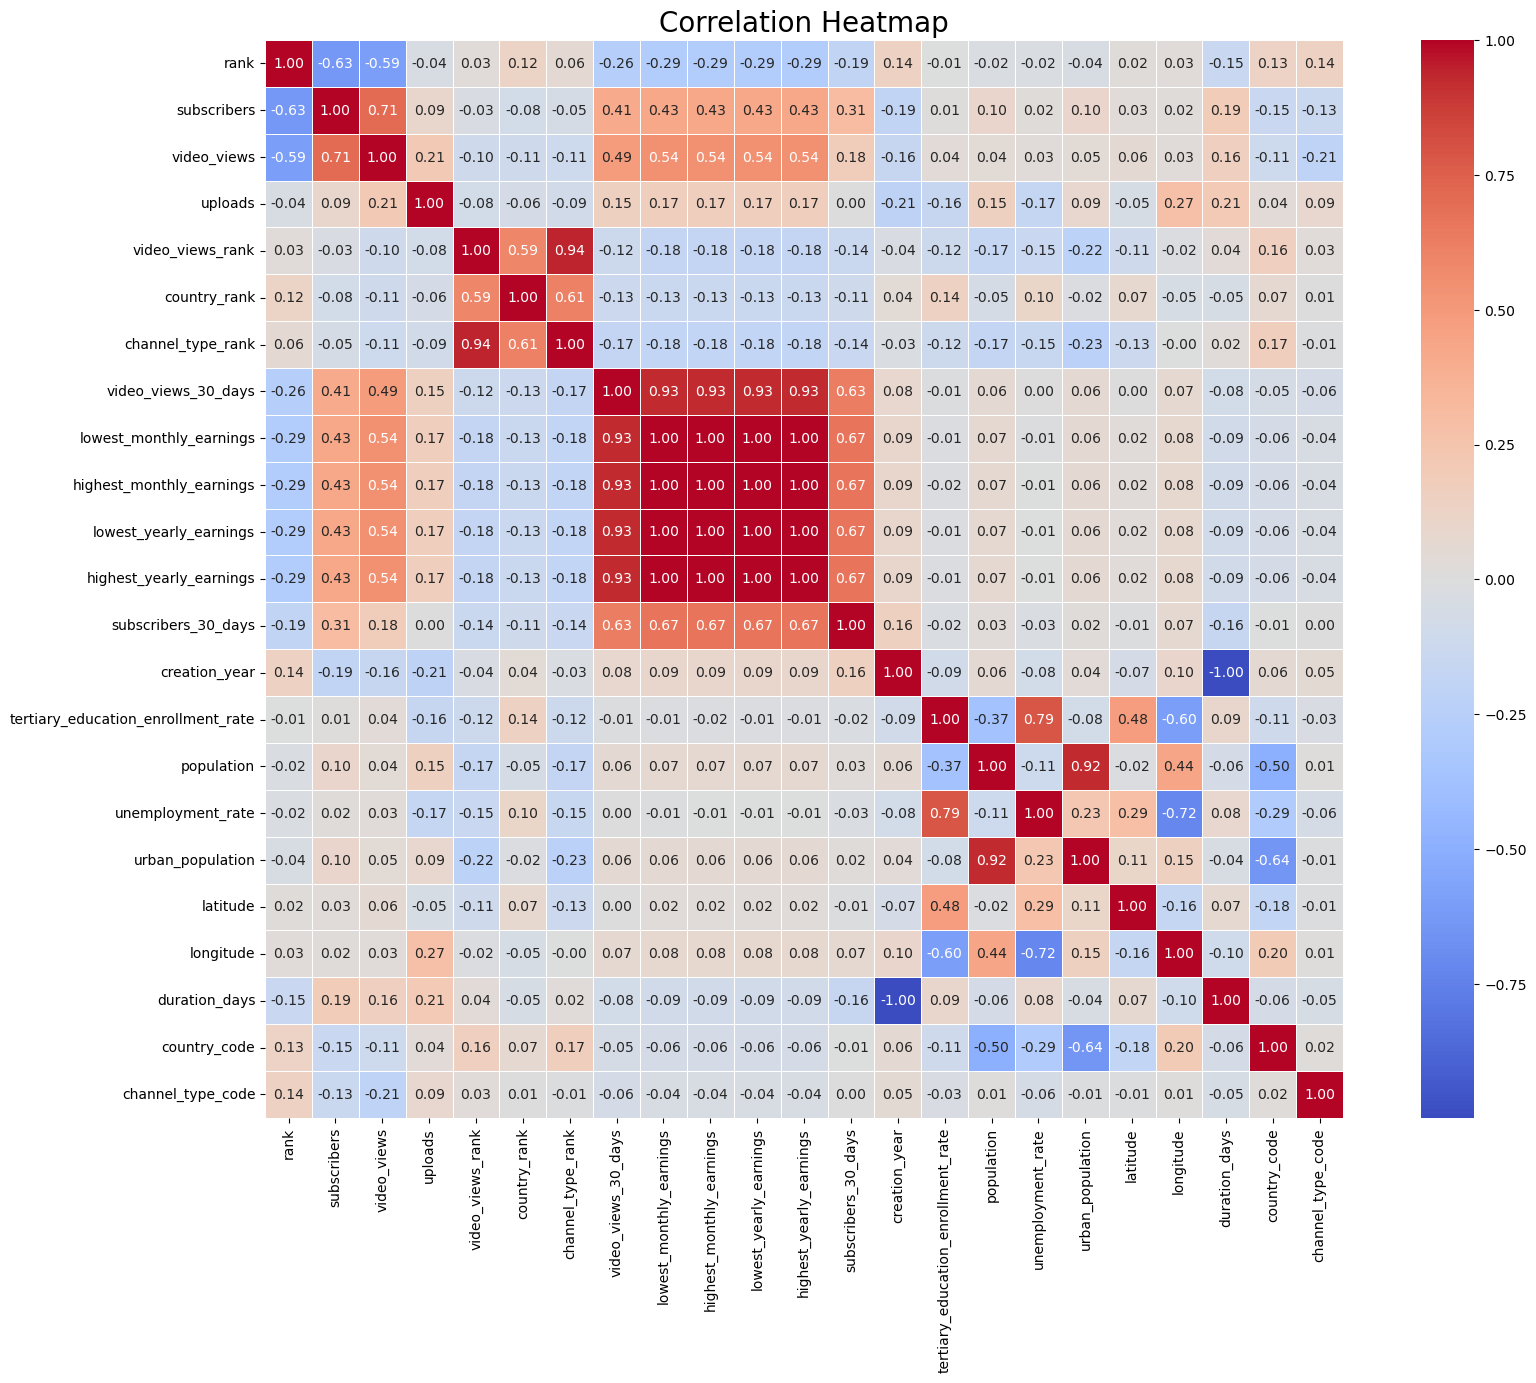

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 计算相关性矩阵
correlation_matrix = df.corr()

# 设置绘图大小
plt.figure(figsize=(20, 14))

# 绘制热力图
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)

# 设置标题
plt.title('Correlation Heatmap',fontsize = 20)
plt.show()